## Load modules

In [1]:
from tqdm import tqdm

import numpy as np
import scipy
from scipy import constants
from scipy.stats import beta
import mpmath

# import qgm
from qgm import function
from qgm import image
from qgm import fitting
from qgm import parameter
from qgm.deconvolution import deconvolution

import matplotlib.pyplot as plt
import matplotlib.patches as patches


## Set image settings

In [2]:
img_setting = parameter.system()

img_setting.set_defaults()
img_setting.psf.set_defaults()

### Point Spread Function (PSF)

In [3]:
if True:
    psf_info = {'Model':'psf',
                'Effective NA': 0.6,
                'Offset count': 0,
                'Peak count': 2500,
                'Wavelength (um)': 0.78
            }
else:
    psf_info = {'Model':'psf',
                'Effective NA': 0.65,
                'Offset count': 0,
                'Peak count': 2500,
                'Wavelength (um)': 0.42
            }

In [4]:
img_setting.psf.set_info(**psf_info)
img_setting.psf.recalc_resolution()
img_setting.psf.info

{'Model': 'psf',
 'Effective NA': 0.6,
 'Wavelength (um)': 0.78,
 'Peak count': 2500,
 'HWHM width - iso (um)': 0.3344230402377111,
 'HWHM width - x (um)': 0.3344230402377111,
 'HWHM width - y (um)': 0.3344230402377111,
 'Offset count': 0,
 'R abbe (um)': 0.65,
 'R Rayleigh (um)': 0.7927854293232279}

### Lattice information

In [5]:
if True:
    lattice1_info = {'Constant (px)': 3.77013,
                    'Constant (um)': 3.77013 * 0.18782061063985978,
                    'Angle (degree)': 19.81638,
                    'Angle (radian)': 19.81638 * np.pi / 180,
                    }
    lattice2_info = {'Constant (px)': 3.78842,
                    'Constant (um)': 3.78842 * 0.18782061063985978,
                    'Angle (degree)': 79.61159,
                    'Angle (radian)': 79.61159 * np.pi / 180,
                    }
else:
    lattice1_info = {'Constant (px)': 3.77013 / 2,
                    'Constant (um)': 3.77013 * 0.18782061063985978 / 2,
                    'Angle (degree)': 19.81638,
                    'Angle (radian)': 19.81638 * np.pi / 180,
                    }
    lattice2_info = {'Constant (px)': 3.78842 / 2,
                    'Constant (um)': 3.78842 * 0.18782061063985978 / 2,
                    'Angle (degree)': 79.61159,
                    'Angle (radian)': 79.61159 * np.pi / 180,
                    }

In [6]:
img_setting.lattice['Lattice 1'].set_info(**lattice1_info)
img_setting.lattice['Lattice 2'].set_info(**lattice2_info)

img_setting.lattice['Origins']['X Center (um)'] = np.array([0])
img_setting.lattice['Origins']['Y Center (um)'] = np.array([0])
img_setting.lattice['Origins']['Goodness'] = np.array([1])

### Image center and magnification

In [7]:
img_magnification = 85

img_size = {'x': 25, 'y': 25, 'unit': 'um'}

if img_size['unit'] == 'px':
    size_x = img_size['x']
    size_y = img_size['y']
else:
    size_x = int(img_size['x'] / img_setting.info['Effective Pixel size (um/px)'])
    size_y = int(img_size['y'] / img_setting.info['Effective Pixel size (um/px)'])

In [8]:
system_info = {'Magnification': img_magnification,
               'Cloud center (px)': (size_x/2, size_y/2),
               'Cloud center (um)': (0, 0),
               'EM gain': 300,
               }

In [9]:
img_setting.set_info(**system_info)
img_setting.recalc_effective_pixel_size()

img_setting.info

{'Camera model': 'Andor iXon Ultra DU-897U-CS0-EXF',
 'Camera maker': 'Oxford Instruments',
 'Pixel size (um/px)': 16,
 'Effective Pixel size (um/px)': 0.18823529411764706,
 'Magnification': 85,
 'EM gain': 300,
 'Pre amp.': 3,
 'HS speed (MHz)': 17.0,
 'VS speed (us/px)': 3.3,
 'Temperature': -75,
 'Objective NA': 0.65,
 'Cloud center (px)': (66.0, 66.0),
 'Cloud center (um)': (0, 0)}

## Mott insulator

### Functions

In [10]:
def calc_mu_local(xs, ys, mu, omega_x, omega_y):
    return mu - 86.909180520 * constants.m_u * (omega_x**2 * ys**2 + omega_y**2 * xs**2) / 2

In [11]:
def Est_Atom_dist(T, mu_local, U, Nmax=10):
  ## Calcuration maximum occupancy
  beta_val = 1 / (constants.k * T)

  Pr = np.zeros([mu_local.size, Nmax])
  Nreal = np.zeros([mu_local.size, Nmax])
  Ndet = np.zeros([mu_local.size, Nmax])
  
  Z = np.zeros(mu_local.shape) # Grand canonical partition function
  
  for N in range(Nmax):
    En = N * (N - 1) * U / 2
    
    Pr[:, N] = np.exp((mu_local * N - En) * beta_val)
    Nreal[:, N] = N * Pr[:, N]
    Ndet[:, N] = np.mod(N, 2) * Pr[:, N]
    
    Z += Pr[:, N]
    
  for N in range(Nmax):
    Pr[:, N] /= Z
    Nreal[:, N] /= Z
    Ndet[:, N] /= Z
  
  Nreal = np.sum(Nreal, 1)
  Ndet = np.sum(Ndet, 1)
  Ndet = (Ndet - np.min(Ndet)) / (np.max(Ndet) - np.min(Ndet))

  Ntotal = np.sum(Nreal)

  Sloc = np.zeros(Nreal.shape)
  
  for N in range(Nmax):
    Prn = Pr[:, N]
    Sloc[Prn>0] += - Prn[Prn>0] * np.log(Prn[Prn>0])

  return Nreal, Ndet, Ntotal, Pr, Sloc

### Parameters

In [12]:
# cmap = image.generate_cmap(['#330000', 'r', 'w'])
cmap = image.generate_cmap(['k', 'r', 'w'])

In [13]:
img = image.image()
img.system = img_setting

img.image = np.zeros((size_y, size_x))
img.system.set_info(**system_info)
xy_mesh = img.generate_xymesh()
(xs, ys) = img.generate_lattice_sites(Nsite=201, rxlim=size_x, rylim=size_y, unit='um', limits='square')

In [14]:
omega_x = 2 * np.pi * 40.73 # Hz
omega_y = 2 * np.pi * 75.15 # Hz
omega_x = 2 * np.pi * 2*40.73 # Hz
omega_y = 2 * np.pi * 1.2*75.15 # Hz

# if True:
#     # omega_x *= np.sqrt(0.18914323299979638)
#     # omega_y *= np.sqrt(0.18914323299979638)
#     omega_x *= np.sqrt(0.10943912227293062)
#     omega_y *= np.sqrt(0.10943912227293062)
# # omega_y = omega_x # Hz

if True:
    omega_x = np.sqrt(omega_x**2 + (2 * np.pi * 30)**2)
    omega_y = np.sqrt(omega_y**2 + (2 * np.pi * 30)**2)

U = constants.h * 325.137
mu = 1 * U
mu = 0.3 * U
mu = 0.7 * U
# mu = 2.1 * U

# T = 3 * 1e-9
T = 0.15 * U / constants.k

print('(omega_x, omega_y)/2pi = (%.2f, %.2f) Hz' % (omega_x / (2*np.pi), omega_y / (2*np.pi)))
print('kT/U = %.2f, mu/U = %.2f' % (constants.k * T / U, mu/U))

(omega_x, omega_y)/2pi = (86.81, 95.04) Hz
kT/U = 0.15, mu/U = 0.70


In [15]:
2.96e-3*np.exp(1.43 * 6.04), 2.93e-3*np.exp(1.43 * 4.5), 2.93e-3*np.exp(1.43 * 5), (2.93e-3*np.exp(1.43 * 4.5))/(2.96e-3*np.exp(1.43 * 6.04))

(np.float64(16.687067018281528),
 np.float64(1.8262179677902999),
 np.float64(3.733130448658217),
 np.float64(0.10943912227293062))

### Estimate atom distribution

In [16]:
mu_local = calc_mu_local(xs*1e-6, ys*1e-6, mu, omega_x, omega_y)
Nreal, Ndet, Ntotal, Pr, Sloc = Est_Atom_dist(T, mu_local, U)

S_total = np.sum(Sloc)
# T_Tc_val = float(((np.sum(Sloc) / Ntotal) * mpmath.zeta(3) / (4 * mpmath.zeta(4)))**(1/3)) # T/Tc?

S_total, Ntotal, S_total / Ntotal

(np.float64(36.714531753358266),
 np.float64(47.643506044484),
 np.float64(0.7706093610969453))

In [17]:
np.random.seed(0)

img_fidelity = 0.95

pos_bool = Ndet >= np.random.rand(Ndet.size)
xs_ex_ideal = xs[pos_bool]
ys_ex_ideal = ys[pos_bool]

p = np.random.rand(xs_ex_ideal.size) <= img_fidelity
xs_ex = xs_ex_ideal[p]
ys_ex = ys_ex_ideal[p]

Nex_ideal = len(xs_ex_ideal)
Nex = len(xs_ex)

In [18]:
# definitions for the axes
left, width = 0.1, 0.33
bottom, height = 0.1, 0.3
cbar_height, cbar_width = 0.025, 0.3
spacing_height, spacing_width = 0.05, 0.02

rect_chemical_potential     = [left, bottom+height+spacing_height, width, height]
rect_entropy                = [left+width+spacing_width, bottom+height+spacing_height, width, height]
rect_atom_distribution      = [left, bottom, width, height]
rect_parity_distribution    = [left+width+spacing_width, bottom, width, height]
rect_simulated_distribution = [left+2*(width+spacing_width), bottom, width, height]

rect_cbar_chemical_potential     = [left, bottom+2*height+2*spacing_height, cbar_width, cbar_height]
rect_cbar_entropy                = [left+width+spacing_width, bottom+2*height+2*spacing_height, cbar_width, cbar_height]
rect_cbar_atom_distribution      = [left, bottom+height, cbar_width, cbar_height]
rect_cbar_parity_distribution    = [left+width+spacing_width, bottom+height, cbar_width, cbar_height]

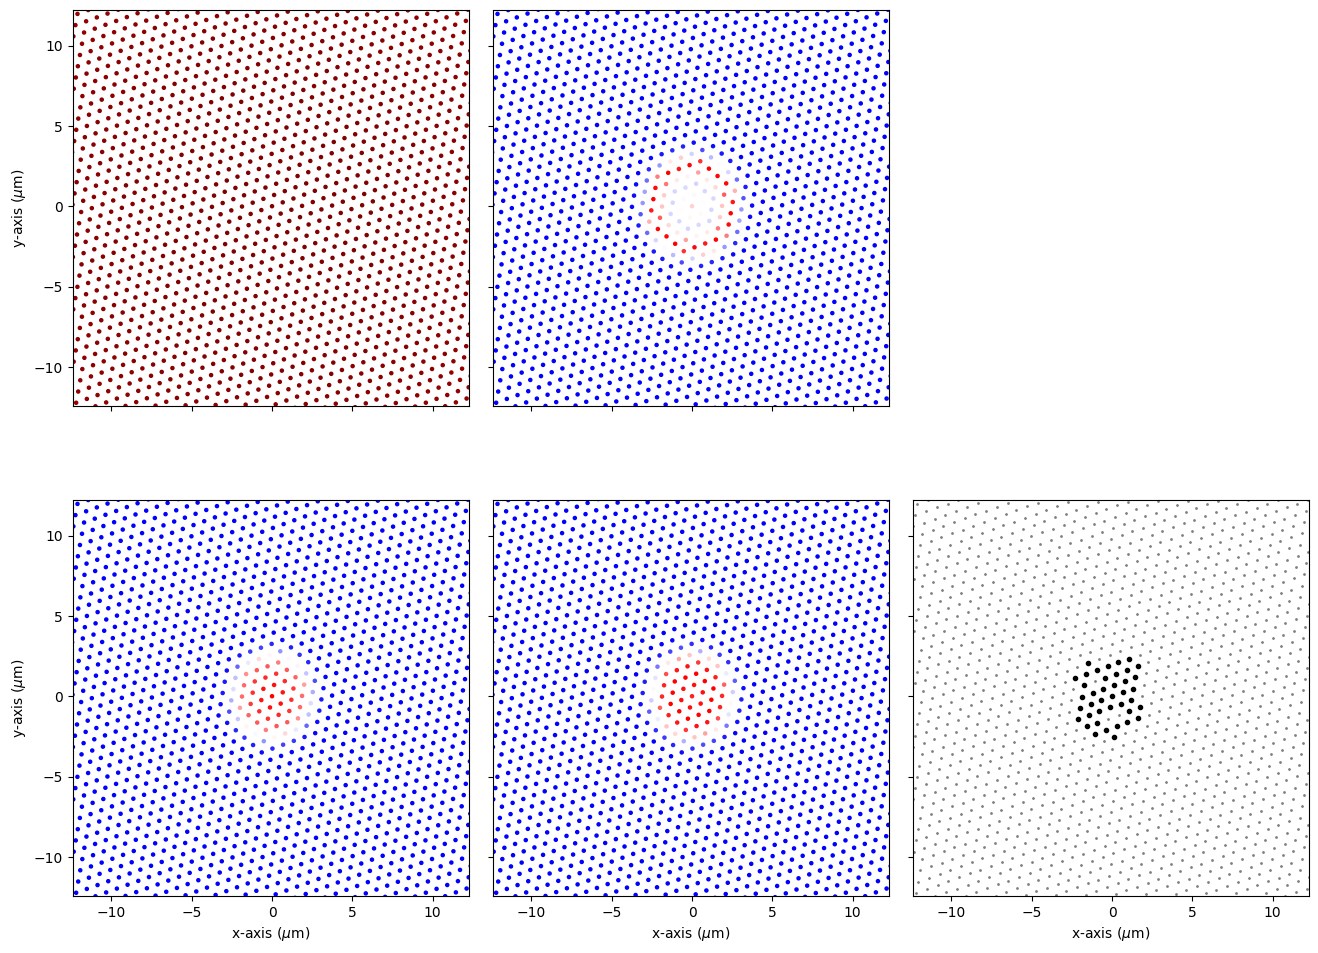

In [19]:
fig = plt.figure(figsize=(12, 14), dpi=100)

ax_chemical_potential       = fig.add_axes(rect_chemical_potential)
ax_entropy                  = fig.add_axes(rect_entropy, sharex=ax_chemical_potential, sharey=ax_chemical_potential)
ax_atom_distribution        = fig.add_axes(rect_atom_distribution, sharex=ax_chemical_potential, sharey=ax_chemical_potential)
ax_parity_distribution      = fig.add_axes(rect_parity_distribution, sharex=ax_chemical_potential, sharey=ax_chemical_potential)
ax_simulated_distribution   = fig.add_axes(rect_simulated_distribution, sharex=ax_chemical_potential, sharey=ax_chemical_potential)

# ax_cbar_chemical_potential  = fig.add_axes(rect_cbar_chemical_potential)
# ax_cbar_entropy             = fig.add_axes(rect_cbar_entropy)
# ax_cbar_atom_distribution   = fig.add_axes(rect_cbar_atom_distribution)
# ax_cbar_parity_distribution = fig.add_axes(rect_cbar_parity_distribution)

ax_chemical_potential.tick_params(axis='x', labelbottom=False)
ax_entropy.tick_params(axis='x', labelbottom=False)
ax_entropy.tick_params(axis='y', labelleft=False)
ax_parity_distribution.tick_params(axis='y', labelleft=False)
ax_simulated_distribution.tick_params(axis='y', labelleft=False)


# Chemical potential
plt_chemical_potential = ax_chemical_potential.scatter(xs, ys, c=mu_local/constants.k*1e6, cmap='jet', s=5)

# cbar_chemical_potential = plt.colorbar(plt_chemical_potential, cax=ax_cbar_chemical_potential, orientation='horizontal')
# cbar_chemical_potential.ax.set_title('Chemical potnetial $\mu/k_B$ ($\mu$K)')

ax_chemical_potential.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
ax_chemical_potential.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
ax_chemical_potential.set_ylabel('y-axis ($\mu$m)')

# Entropy
plt_entropy = ax_entropy.scatter(xs, ys, c=Sloc, cmap='bwr', vmin=0, s=5)

# cbar_entropy = plt.colorbar(plt_entropy, cax=ax_cbar_entropy, orientation='horizontal')
# cbar_entropy.ax.set_title(r'Local entropy $S_{loc}/k_B$')

# g.set_title('Total entropy $S/k_B$ = %d\n Entropy per particle $S/(N k_B)$ = %.3f\n $T_\mathrm{BEC}/T_C$ = %.3f' % (S_total, S_total / Ntotal, T_Tc_val))

# Ideal atom distribution
plt_atom_distribution = ax_atom_distribution.scatter(xs, ys, c=Nreal, cmap='bwr', s=5)

# cbar_atom_distribution = plt.colorbar(plt_atom_distribution, cax=ax_cbar_atom_distribution, orientation='horizontal')
# cbar_atom_distribution.ax.set_title('Chemical potnetial $\mu/k_B$ ($\mu$K)')

ax_atom_distribution.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
ax_atom_distribution.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

ax_atom_distribution.set_xlabel('x-axis ($\mu$m)')
ax_atom_distribution.set_ylabel('y-axis ($\mu$m)')

# bar.set_label('Number of atoms')

# Parity measurement
plt_parity_distribution = ax_parity_distribution.scatter(xs, ys, c=Ndet, cmap='bwr', vmin=0, s=5)

# cbar_parity_distribution = plt.colorbar(plt_parity_distribution, cax=ax_cbar_parity_distribution, orientation='horizontal')
# cbar_parity_distribution.ax.set_title('Chemical potnetial $\mu/k_B$ ($\mu$K)')

ax_parity_distribution.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
ax_parity_distribution.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
ax_parity_distribution.set_xlabel('x-axis ($\mu$m)')

# Simulated distribution
ax_simulated_distribution.plot(xs, ys, '.', color='gray', ms=2)
ax_simulated_distribution.plot(xs_ex, ys_ex, 'ko', ms=3)

ax_simulated_distribution.set_aspect('equal')
ax_simulated_distribution.set_xlabel('x-axis ($\mu$m)')

# ax.text(np.max(x)+3, np.max(y)+16, 'Seq. No = %d' % 0, color='k', fontsize=17)

ax_chemical_potential.set_aspect(1)
ax_entropy.set_aspect(1)
ax_atom_distribution.set_aspect(1)
ax_parity_distribution.set_aspect(1)
ax_simulated_distribution.set_aspect(1)

# plt.tight_layout()

# plt.suptitle('test')

plt.show()

In [20]:
xs, ys

(array([-79.4482338 , -78.78205709, -78.11588038, ...,  78.11588038,
         78.78205709,  79.4482338 ]),
 array([-93.99332465, -93.75327112, -93.51321759, ...,  93.51321759,
         93.75327112,  93.99332465]))

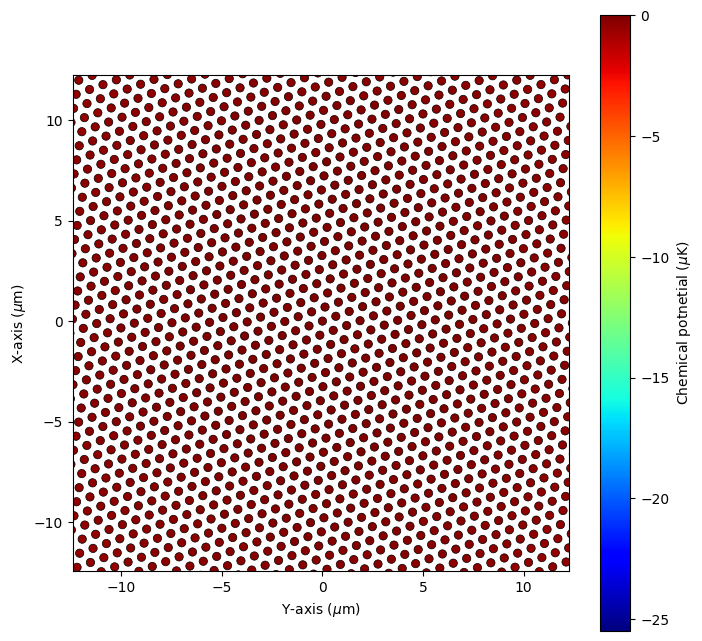

In [21]:
fig = plt.figure(dpi=100, figsize=(8, 8))
g = plt.subplot()

plt1 = g.scatter(xs, ys, c=mu_local/constants.k*1e6, cmap='jet', ec='k', lw=0.5)

bar = plt.colorbar(plt1)
bar.set_label('Chemical potnetial ($\mu$K)')

g.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
g.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
# g.set_xlim(np.max(xs), np.min(xs))
# g.set_ylim(np.min(ys), np.max(ys))
g.set_xlabel('Y-axis ($\mu$m)')
g.set_ylabel('X-axis ($\mu$m)')

g.set_aspect('equal')

plt.show()

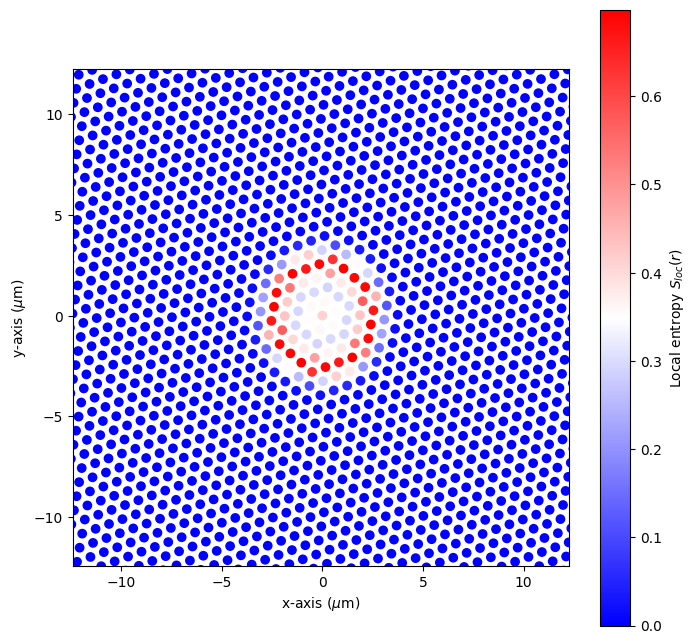

In [22]:
fig = plt.figure(dpi=100, figsize=(8, 8))
g = plt.subplot()

plt1 = g.scatter(xs, ys, c=Sloc, cmap='bwr', vmin=0)

bar = plt.colorbar(plt1)
bar.set_label(r'Local entropy $S_{loc}(r)$')

# g.set_title('Total entropy $S/k_B$ = %d\n Entropy per particle $S/(N k_B)$ = %.3f\n $T_\mathrm{BEC}/T_C$ = %.3f' % (S_total, S_total / Ntotal, T_Tc_val))
g.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
g.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
# g.set_xlim(np.max(xs), np.min(xs))
# g.set_ylim(np.min(ys), np.max(ys))
g.set_xlabel('x-axis ($\mu$m)')
g.set_ylabel('y-axis ($\mu$m)')

g.set_aspect('equal')

plt.show()

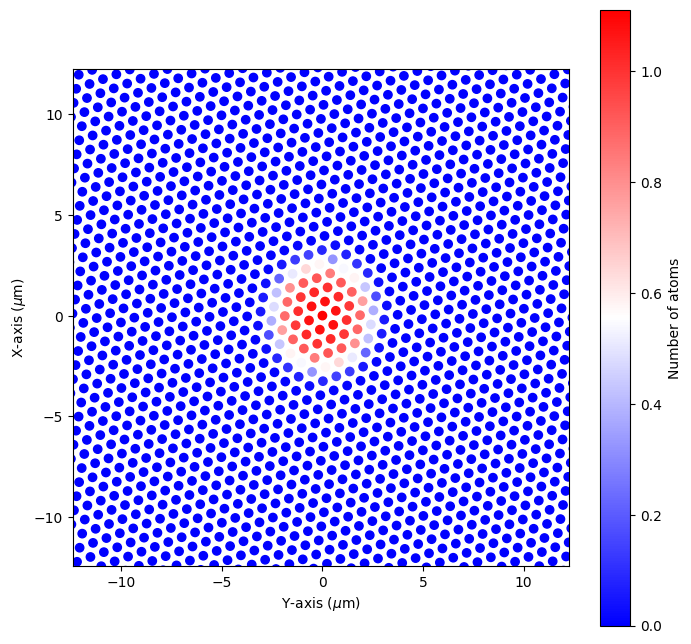

In [23]:
fig = plt.figure(dpi=100, figsize=(8, 8))
g = plt.subplot()

plt1 = g.scatter(xs, ys, c=Nreal, cmap='bwr')

bar = plt.colorbar(plt1)
bar.set_label('Number of atoms')

g.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
g.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
# g.set_xlim(np.max(xs), np.min(xs))
# g.set_ylim(np.min(ys), np.max(ys))
g.set_xlabel('Y-axis ($\mu$m)')
g.set_ylabel('X-axis ($\mu$m)')

g.set_aspect('equal')

plt.show()

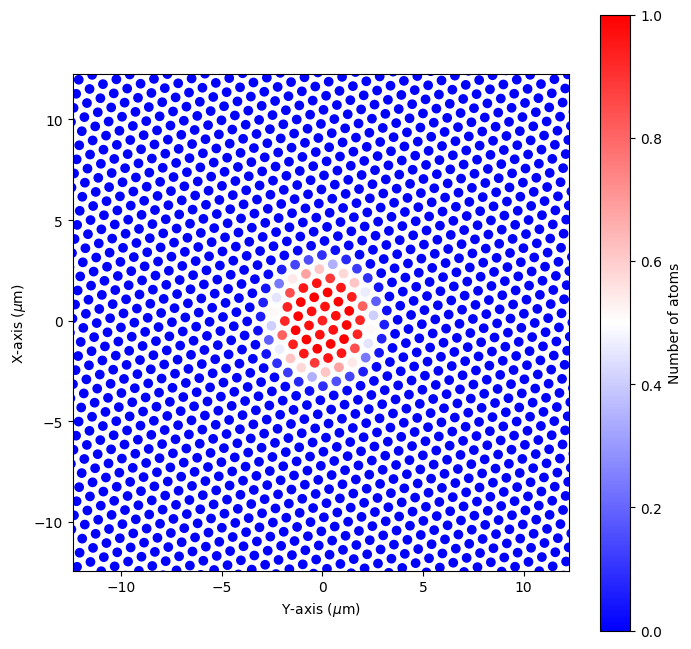

In [24]:
fig = plt.figure(dpi=100, figsize=(8, 8))
g = plt.subplot()

plt1 = g.scatter(xs, ys, c=Ndet, cmap='bwr', vmin=0)

bar = plt.colorbar(plt1)
bar.set_label('Number of atoms')

g.set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
g.set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))
# g.set_xlim(np.max(xs), np.min(xs))
# g.set_ylim(np.min(ys), np.max(ys))
g.set_xlabel('Y-axis ($\mu$m)')
g.set_ylabel('X-axis ($\mu$m)')

g.set_aspect('equal')

plt.show()

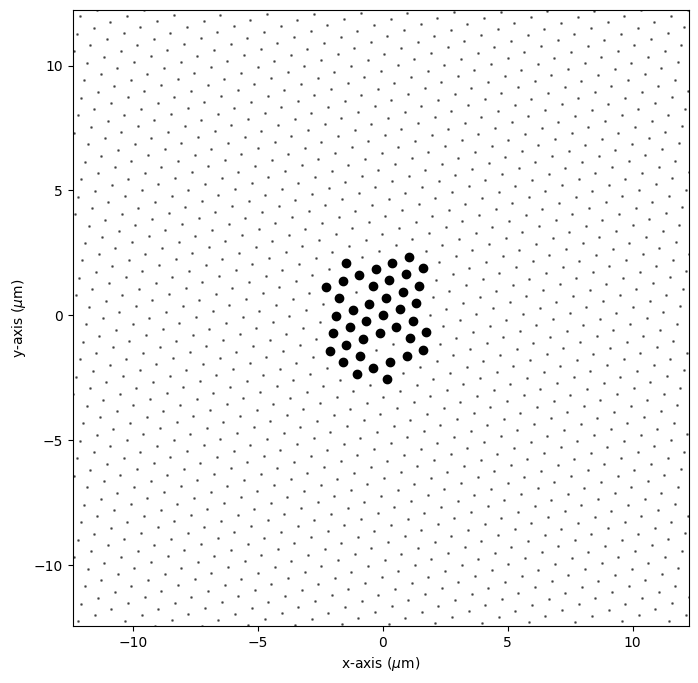

In [25]:
fig = plt.figure(dpi=100, figsize=(8, 8))

plt.plot(xs, ys, 'k.', ms=2, alpha=0.5)

plt.plot(xs_ex, ys_ex, 'ko')
plt.gca().set_aspect('equal')

plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

plt.xlabel('x-axis ($\mu$m)')
plt.ylabel('y-axis ($\mu$m)')

plt.show()

### Generate simulated image

In [26]:
photon = 500
photon_noise = 10
print('S/N = %.2f' % (photon/photon_noise))

Nphs = np.random.poisson(photon, Nex)

xmax = np.max(xs) * 1.25
ymax = np.max(ys) * 1.25

Nsample = 10000
spx_eff = img_setting.info['Effective Pixel size (um/px)']

alpha_psf = 2 * np.pi * img_setting.psf.info['Effective NA'] / img_setting.psf.info['Wavelength (um)']
show_progress = True

S/N = 50.00


In [66]:
Nsample = 100000

In [68]:
img.image *= 0

if show_progress:
    for i in tqdm(range(Nex)):
        N = 0
        p_psf = np.array([1, xs_ex[i], ys_ex[i], alpha_psf, 0])

        xs_rnd = np.array([])
        ys_rnd = np.array([])

        while N < Nphs[i]:
            x_rnd = 2 * xmax * (np.random.rand(Nsample) - 0.5)
            y_rnd = 2 * ymax * (np.random.rand(Nsample) - 0.5)
            z_rnd = np.random.rand(Nsample)
            s = function.psf_2d((x_rnd, y_rnd), *p_psf)
            
            xs_rnd = np.append(xs_rnd, x_rnd[s > z_rnd])
            ys_rnd = np.append(ys_rnd, y_rnd[s > z_rnd])
            
            N = xs_rnd.size

        if N > Nphs[i]:
            xs_rnd = xs_rnd[0:Nphs[i]]
            ys_rnd = ys_rnd[0:Nphs[i]]

            N = xs_rnd.size
        
        for j in range(len(xs_rnd)):
            x_tmp1 = xy_mesh[0] >= xs_rnd[j] - spx_eff
            x_tmp2 = xy_mesh[0] <= xs_rnd[j]
            x_tmp = x_tmp1 * x_tmp2
            y_tmp1 = xy_mesh[1] >= ys_rnd[j] - spx_eff
            y_tmp2 = xy_mesh[1] <= ys_rnd[j] 
            y_tmp = y_tmp1 * y_tmp2

            img.image += x_tmp * y_tmp

Nbgs = np.random.poisson(photon_noise, img.image.shape)
img.image += Nbgs

100%|██████████| 40/40 [04:27<00:00,  6.70s/it]


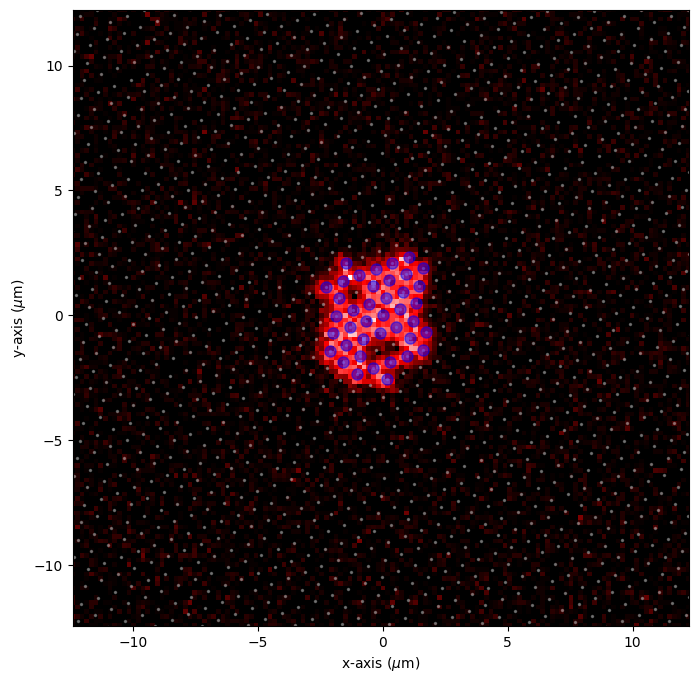

In [28]:
plt.figure(figsize=(8,8), dpi=100)

plt.pcolormesh(xy_mesh[0], xy_mesh[1], img.image, cmap=cmap, vmin=photon_noise)
plt.plot(xs, ys, 'w.', ms=3, alpha=0.3)
plt.plot(xs_ex, ys_ex, 'bo', ms=8, alpha=0.5)
plt.gca().set_aspect('equal')

plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

plt.xlabel('x-axis ($\mu$m)')
plt.ylabel('y-axis ($\mu$m)')

plt.show()

#### Develop

In [29]:
img_comp = np.zeros(img.image.shape)

show_progress = True
if show_progress:
    # x_smaple = np.arange(np.min(xs) - 10 * spx_eff, np.max(xs) + 10 * spx_eff, spx_eff/10)
    # y_smaple = np.arange(np.min(ys) - 10 * spx_eff, np.max(ys) + 10 * spx_eff, spx_eff/10)

    # xy_mesh_sample = np.meshgrid(x_smaple, y_smaple)

    for i in tqdm(range(Nex)):
        # print(i)
        N = 0
        p_psf = np.array([1, xs_ex[i], ys_ex[i], alpha_psf, 0])

        # p_atom_i = function.psf_2d(xy_mesh_sample, *p_psf)

        # xs_rnd = np.array([])
        # ys_rnd = np.array([])
        xs_rnd = []
        ys_rnd = []

        gain_sample = 100000
        Nsample = gain_sample * Nphs[i]

        while N < Nphs[i]:
            x_rnd = 2 * xmax * (np.random.rand(Nsample) - 0.5)
            y_rnd = 2 * ymax * (np.random.rand(Nsample) - 0.5)
            z_rnd = np.random.rand(Nsample)
            s = function.psf_2d((x_rnd, y_rnd), *p_psf)
            
            condition_true = s > z_rnd
            # xs_rnd = np.append(xs_rnd, x_rnd[condition_true])
            # ys_rnd = np.append(ys_rnd, y_rnd[condition_true])
            xs_rnd += x_rnd[condition_true].tolist()
            ys_rnd += y_rnd[condition_true].tolist()
            
            N = len(xs_rnd)
            # Nsample = gain_sample * (Nphs[i] - N)
            # print(i, Nphs[i], N, Nsample)
        if N > Nphs[i]:
            xs_rnd = xs_rnd[0:Nphs[i]]
            ys_rnd = ys_rnd[0:Nphs[i]]

            N = len(xs_rnd)
        
        for x_rnd, y_rnd in zip(xs_rnd, ys_rnd):
            x_tmp = (xy_mesh[0] >= x_rnd - spx_eff) * (xy_mesh[0] <= x_rnd)
            y_tmp = (xy_mesh[1] >= y_rnd - spx_eff) * (xy_mesh[1] <= y_rnd)

            img_comp += x_tmp * y_tmp

Nbgs = np.random.poisson(photon_noise, img_comp.shape)
img_comp += Nbgs

100%|██████████| 40/40 [06:25<00:00,  9.64s/it]


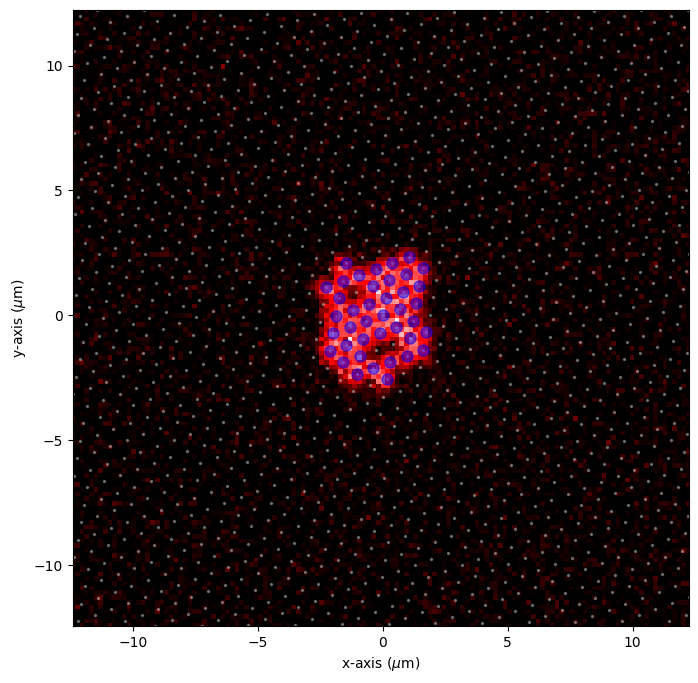

In [30]:
plt.figure(figsize=(8,8), dpi=100)

plt.pcolormesh(xy_mesh[0], xy_mesh[1], img_comp, cmap=cmap, vmin=photon_noise)
plt.plot(xs, ys, 'w.', ms=3, alpha=0.3)
plt.plot(xs_ex, ys_ex, 'bo', ms=8, alpha=0.5)
plt.gca().set_aspect('equal')

plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

plt.xlabel('x-axis ($\mu$m)')
plt.ylabel('y-axis ($\mu$m)')

plt.show()

In [31]:
img.image.shape, np.min(xs), np.max(xs), np.min(ys), np.max(ys), spx_eff

((132, 132),
 np.float64(-79.44823379954322),
 np.float64(79.44823379954322),
 np.float64(-93.99332465493882),
 np.float64(93.99332465493882),
 0.18823529411764706)

In [32]:
x_smaple = np.arange(np.min(xs) - 10 * spx_eff, np.max(xs) + 10 * spx_eff, 10*spx_eff/3)
y_smaple = np.arange(np.min(ys) - 10 * spx_eff, np.max(ys) + 10 * spx_eff, 10*spx_eff/3)

xy_mesh_sample = np.meshgrid(x_smaple, y_smaple)

In [33]:
xy_mesh_sample[0].shape

(306, 260)

In [34]:
%%timeit
function.psf_2d(xy_mesh_sample, *p_psf)

10.5 ms ± 89.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [35]:
# %%timeit
# function.psf_2d_tmp(xy_mesh_sample, *p_psf)
print('dummy')

dummy


In [36]:
from numba import jit
from scipy import special

@jit
def psf_jit(x, y, *p):
    """[summary]
    
    Arguments:
        xy_mesh {[type]} -- [description]
    
    Returns:
        [type] -- [description]
    """    
    # Parameters
    A, x0, y0, alpha, C = p

    xc = x - x0
    yc = y - y0

    r = np.sqrt(xc**2 + yc**2) * alpha
    z = np.zeros(r.shape, dtype=np.float)

    (size1, size2) = r.shape
    
    r = np.ravel(r)
    z = np.ravel(z)

    # for n in range(size1*size2):
    #     if r[n] > 0:
    #         z[n] = A * (2 * special.j1(r[n]) / r[n])**2
    #         # continue
    #     else:
    #         z[n] = A
    # tmp = (r == 0)
    # z[tmp] = A

    # tmp = not tmp
    # z[tmp] = A * (2 * special.j1(r[r!=0]) / r[r!=0])**2

    # z = z.reshape([size1, size2])
    # return z.reshape([size1, size2]) + C
    return z + C

def psf_2d_test(xy_mesh, *p):
    """[summary]
    
    Arguments:
        xy_mesh {[type]} -- [description]
    
    Returns:
        [type] -- [description]
    """    
    # unpack 1D list into 2D x and y coords
    (x, y) = xy_mesh
    
    z = psf_jit(x, y, *p)
    return z.reshape(x.shape)

In [37]:
# function.psf_2d(xy_mesh_sample, *p_psf)
# psf_2d_test(xy_mesh_sample, *p_psf)
# p_psf

In [38]:
function.psf_2d(xy_mesh_sample, *p_psf)

array([[2.96240602e-09, 1.08349202e-08, 1.95614771e-10, ...,
        7.09148775e-09, 7.70873727e-09, 3.61448778e-10],
       [1.06871928e-08, 3.47029821e-09, 4.19442808e-09, ...,
        1.71669625e-10, 1.02437615e-08, 3.88725306e-09],
       [8.16736786e-09, 4.94941476e-10, 1.14366903e-08, ...,
        4.56325189e-09, 2.45499683e-09, 1.08555069e-08],
       ...,
       [9.85236420e-09, 7.51386894e-09, 1.00566073e-09, ...,
        5.15654509e-10, 1.13640054e-08, 4.73849560e-09],
       [7.58840868e-10, 1.21354477e-08, 3.37600319e-09, ...,
        9.25743191e-09, 7.64346813e-09, 4.51452348e-10],
       [3.74514488e-09, 3.76753953e-09, 1.19018876e-08, ...,
        1.03765537e-08, 4.96320350e-11, 8.95241990e-09]])

In [39]:
psf_2d_test(xy_mesh_sample, *p_psf)

AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [55]:
# xy_mesh_sample = 

In [56]:
# plt.figure(figsize=(8,8), dpi=100)

# plt.pcolormesh(xy_mesh[0], xy_mesh[1], img_comp, cmap=cmap, vmin=photon_noise)
# plt.plot(xs, ys, 'w.', ms=3, alpha=0.3)
# plt.plot(xs_ex, ys_ex, 'bo', ms=8, alpha=0.5)
# plt.gca().set_aspect('equal')

# plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
# plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

# plt.xlabel('x-axis ($\mu$m)')
# plt.ylabel('y-axis ($\mu$m)')

# plt.show()

In [57]:
# plt.figure(figsize=(8,8), dpi=100)

# plt.pcolormesh(xy_mesh[0], xy_mesh[1], img.image - img_comp, cmap=cmap)
# plt.plot(xs, ys, 'w.', ms=3, alpha=0.3)
# plt.plot(xs_ex, ys_ex, 'bo', ms=8, alpha=0.5)
# plt.gca().set_aspect('equal')

# plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
# plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

# plt.xlabel('x-axis ($\mu$m)')
# plt.ylabel('y-axis ($\mu$m)')

# plt.show()

In [58]:
# np.min(np.abs(img.image - img_comp)), np.max(np.abs(img.image - img_comp))

### Deconvolution

In [40]:
x0, x1, y0, y1 = [-img_size['x']/2, img_size['x']/2, -img_size['y']/2, img_size['y']/2]

img.set_ROI(ROI= [x0, x1, y0, y1])
xymesh_ROI = img.xymesh_ROI

(xs1_test, ys1_test) = img.generate_lattice_sites(Nsite=401, rxlim=np.max([x0, x1])+1, rylim=np.max([y0, y1])+1, unit='um', limits='square', origin='average')

xs1_test = img.system.lattice['Lattice sites']['X Center']
ys1_test = img.system.lattice['Lattice sites']['Y Center']

In [41]:
img.generate_psfm(psf_model='gaussian')
img_test_dec, factor_evol1 = deconvolution(img, Niter=10)

xs_est = img.system.lattice['Lattice sites']['X Center']
ys_est = img.system.lattice['Lattice sites']['Y Center']
amp_est = img.system.lattice['Lattice sites']['Amplitude']

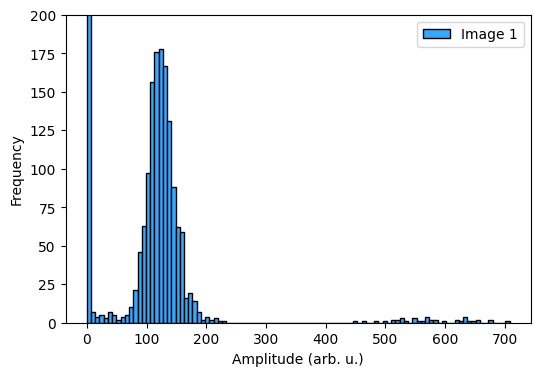

In [42]:
fig, axs = plt.subplots(1, 1, sharex=True, dpi=100, figsize=(6 ,4))

# Remove horizontal space between axes
fig.subplots_adjust(hspace=0.2)

for ax, A, legend_label in zip([axs],
                                 [img.system.lattice['Lattice sites']['Amplitude']],
                                 ['Image 1']):
    ax.hist(A, bins=100, ec='k', fc='#33aaff', label=legend_label)
    ax.set_ylim(0, 200)

    # ax.vlines(20000, ymin=0, ymax=10000, color='gray', ls='--')
    
    ax.legend()
    ax.set_ylabel('Frequency')

plt.xlabel('Amplitude (arb. u.)')

plt.show()

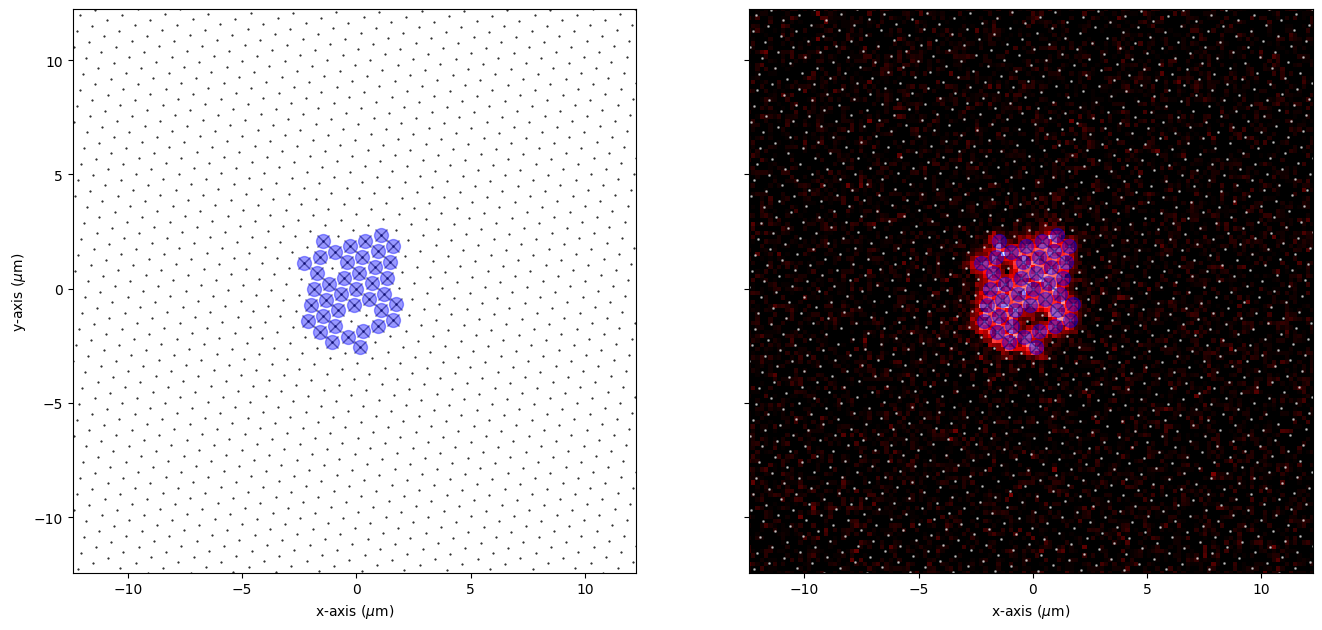

In [43]:
deconv_threshold = 350

fig, axs = plt.subplots(1, 2, figsize=(16,8), dpi=100, sharex=True, sharey=True)

axs[1].pcolormesh(xy_mesh[0], xy_mesh[1], img.image, cmap=cmap, vmin=photon_noise)
axs[0].plot(xs, ys, 'k.', ms=1)
axs[1].plot(xs, ys, 'w.', ms=2, alpha=0.5)

for ax in axs:
    ax.plot(xs_ex, ys_ex, 'kx', ms=8, alpha=0.5)
    ax.plot(xs_est[amp_est > deconv_threshold], ys_est[amp_est > deconv_threshold], 'bo', ms=10, alpha=0.4)
    
    ax.set_aspect('equal')
    ax.set_xlabel('x-axis ($\mu$m)')

axs[0].set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
axs[0].set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))


axs[0].set_ylabel('y-axis ($\mu$m)')

plt.show()

### Evaluate Filling

In [44]:
def gauss_no_offset(x, *p):
    A, x0, sigma = p
    
    return function.gaussian_1d(x, *[A, x0, sigma, 0])

In [45]:
# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.02

rect_sites = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]


In [46]:
xs_dec = xs_est[amp_est > deconv_threshold]
ys_dec = ys_est[amp_est > deconv_threshold]

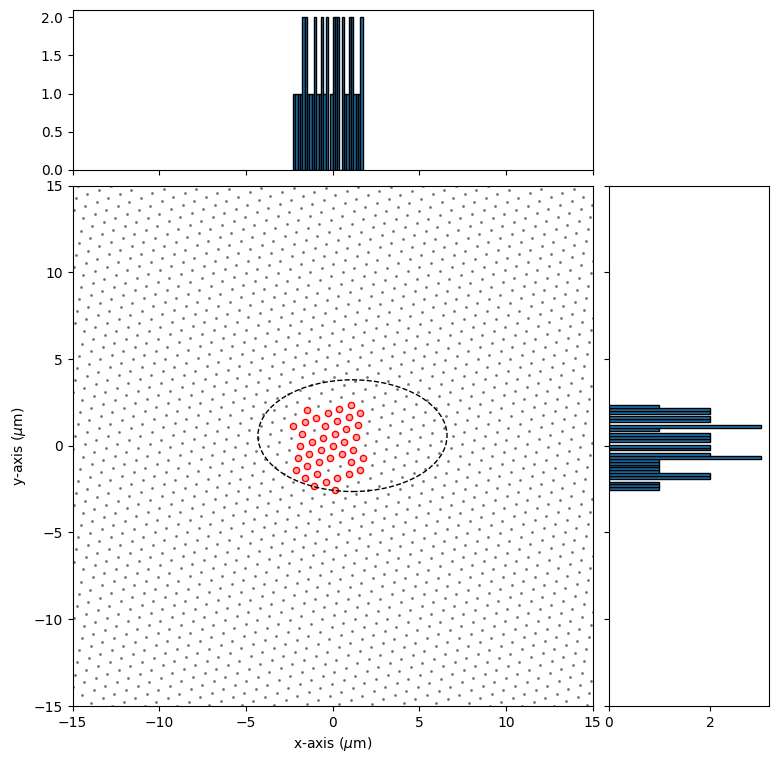

In [47]:

fig = plt.figure(figsize=(8, 8), dpi=100)

ax = fig.add_axes(rect_sites)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

ax.scatter(xs, ys, marker='.', s=4, fc='#777777', zorder=0)
ax.scatter(xs_dec, ys_dec, s=20, marker='o', fc='#ffaaaa', ec='r')

ax.set_xlim([-15, 15])
ax.set_ylim([-15, 15])

ax.set_xlabel('x-axis ($\mu$m)')
ax.set_ylabel('y-axis ($\mu$m)')

bins_fit = np.linspace(-15, 15, 1001)

fx, edgex, _ = ax_histx.hist(xs_dec, bins=30, ec='k')
xbins = edgex[:-1] + (edgex[1] - edgex[0])/2
# p_histx_ini = [np.max(fx), 0, 3, 0]
p_histx_ini = [np.max(fx), 0, 3]
# p_histx_fit, p_histx_err, goodness_histx = fitting.fit_1d(function.gaussian_1d, fx, xbins, p_histx_ini)
p_histx_fit, p_histx_err, goodness_histx = fitting.fit_1d(gauss_no_offset, fx, xbins, p_histx_ini)
# ax_histx.plot(bins_fit, function.gaussian_1d(bins_fit, *p_histx_fit)-p_histx_fit[-1], 'r-', alpha=0.75)
# ax_histx.plot(bins_fit, function.gaussian_1d(bins_fit, *p_histx_fit), 'r-', alpha=0.75)

fy, edgey, _ = ax_histy.hist(ys_dec, bins=30, ec='k', orientation='horizontal')
ybins = edgey[:-1] + (edgey[1] - edgey[0])/2
# p_histy_ini = [np.max(fy), 0, 3, 0]
p_histy_ini = [np.max(fy), 0, 3]
p_histy_fit, p_histy_err, goodness_histy = fitting.fit_1d(gauss_no_offset, fy, ybins, p_histy_ini)
# ax_histy.plot(function.gaussian_1d(bins_fit, *p_histy_fit)-p_histy_fit[-1], bins_fit, 'r-', alpha=0.75)

cx_comp = p_histx_fit[1]
cy_comp = p_histy_fit[1]
rx_comp = p_histx_fit[2] / 1.5
ry_comp = p_histy_fit[2] / 1.5

e = patches.Ellipse(xy=(cx_comp, cy_comp), width=2*rx_comp, height=2*ry_comp, fc='none', ec='k', ls='--')
ax.add_patch(e)

# Nsite_all = np.sum(((x0_all - cx_comp)**2/rx_comp**2 + (y0_all - cy_comp)**2/ry_comp**2) < 1)
# Nsite_exit = np.sum(((x0 - cx_comp)**2/rx_comp**2 + (y0 - cy_comp)**2/ry_comp**2) < 1)

# ax.set_title('Seq. No = %d, Filling = %.3f/%.3f' % (index_filling, filling[index_filling], Nsite_exit/Nsite_all), y=-0.15)

ax.set_aspect(1)
# plt.tight_layout()

plt.show()

In [48]:
cx_comp, rx_comp, cy_comp, ry_comp

(np.float64(1.1506781146541092),
 np.float64(5.454390153172572),
 np.float64(0.5794936066599197),
 np.float64(3.221937090407954))

#### Fit

In [49]:
def filling_mod(r, *p):
    T, mu0, r0 = p
    
    mu_local = np.array(mu0 - r**2/r0**2)

    P_all = np.zeros(mu_local.shape)
    Z = np.zeros(mu_local.shape)

    for n in range(5):
        P = np.exp(n / T * (mu_local - (n-1)/2))
        Z += P
        P_all += np.mod(n, 2) * P

    return P_all /Z

In [50]:
def calc_Sloc(r, *p):
  T, mu0, r0 = p

  mu_local = np.array(mu0 - r**2/r0**2)

  Nmax = 5

  P = np.zeros([mu_local.size, Nmax])
  Nreal = np.zeros([mu_local.size, Nmax])
  Z = np.zeros(mu_local.shape)
  S = np.zeros(mu_local.shape)

  for n in range(Nmax):
      P[:, n] = np.exp(n / T * (mu_local - (n-1)/2))
      Nreal[:, n] = n * np.exp(n / T * (mu_local - (n-1)/2))
      # Nreal[:, n] = n * Pr[:, n]
      Z += P[:, n]

  for n in range(Nmax):
    P[:, n] = P[:, n] / Z
    Nreal[:, n] = Nreal[:, n] / Z
    S += P[:, n] * np.log(P[:, n])

  S *= -constants.k
  
  return S, Nreal

  # Pr = np.zeros([mu_local.size, Nmax])
  # Nreal = np.zeros([mu_local.size, Nmax])
  # Ndet = np.zeros([mu_local.size, Nmax])


  # Z = np.zeros(mu_local.shape) # Grand canonical partition function
  
  # for N in range(Nmax):
  #   En = N * (N - 1) * U / 2
    
  #   Pr[:, N] = np.exp((mu_local * N - En) * beta_val)
  #   Nreal[:, N] = N * Pr[:, N]
  #   Ndet[:, N] = np.mod(N, 2) * Pr[:, N]
    
  #   Z += Pr[:, N]
    
  # for N in range(Nmax):
  #   Pr[:, N] /= Z
  #   Nreal[:, N] /= Z
  #   Ndet[:, N] /= Z
  
  # Nreal = np.sum(Nreal, 1)
  # Ndet = np.sum(Ndet, 1)
  # Ndet = (Ndet - np.min(Ndet)) / (np.max(Ndet) - np.min(Ndet))

  # Ntotal = np.sum(Nreal)

  # Sloc = np.zeros(Nreal.shape)
  
  # for N in range(Nmax):
  #   Prn = Pr[:, N]
  #   Sloc[Prn>0] += - Prn[Prn>0] * np.log(Prn[Prn>0])

  # return Nreal, Ndet, Ntotal, Pr, Sloc

In [51]:
def Clopper_Pearson_Confidence(n, x, alpha):
    lower_limit = beta.ppf(alpha/2, x, n-x+1)
    upper_limit = beta.ppf(1-alpha/2, x+1, n-x)

    return [lower_limit, upper_limit]

In [52]:
r = np.sqrt((xs_est - cx_comp)**2/rx_comp**2 + (ys_est - cy_comp)**2/ry_comp**2) * np.sqrt(rx_comp * ry_comp)

In [53]:
n_exit = amp_est > deconv_threshold

r.size, n_exit.size, xs.size
# n_exit, x0_all

(1673, 1673, 40401)

In [54]:
a1 = 3.770261 * 0.18782061063985978
a2 = 3.792326 * 0.18782061063985978

a_mean = np.mean([a1, a2])
dsite = 1.5
r_sites = np.arange(dsite, int(np.max(r)/a_mean)+1, dsite)

n_occupied = []
n_occupied_std = []

for r_tmp in r_sites:
    condition_r = (r/a_mean >= np.max([r_tmp-dsite/2, 0])) * (r/a_mean < r_tmp+dsite/2)
    n_occupied += [np.mean(n_exit[condition_r])]

    # 68% Clopper-Pearson confidence intervals
    Confidence_limits = Clopper_Pearson_Confidence(np.sum(condition_r), np.sum(n_exit[condition_r]), 1-68/100)
    # Confidence_limits = Clopper_Pearson_Confidence(np.sum(condition_r), np.sum(n_exit[condition_r]), 1-95/100)
    n_occupied_std += [[n_occupied[-1] - Confidence_limits[0], Confidence_limits[1] - n_occupied[-1]]]
    # print(r_tmp, np.sum(condition_r), np.sum(n_exit[condition_r]), Confidence_limits)

n_occupied = np.array(n_occupied)
n_occupied_std = np.array(n_occupied_std).T

# np.max(r)/r_norm, r_sites, n_occupied, n_occupied_std

In [55]:
r_fit = np.arange(-0.1, 30, 0.1)

p_ini = [constants.k * T /U, mu/U, 7] #

fit_condition = (r_sites >= 0) * (r_sites < 50)
# p_fit_occupied, p_err_occupied, goodness_occupied = fitting.fit_1d(filling_mod, n_occupied[fit_condition], r_floor_unique[fit_condition], p_ini)
p_fit_occupied, p_err_occupied, goodness_occupied = fitting.fit_1d(filling_mod, n_occupied[fit_condition], r_sites[fit_condition], p_ini)
# p_fit_occupied, p_err_occupied, goodness_occupied = fitting.fit_1d(filling_mod, n_occupied[fit_condition], r_sites[fit_condition], p_ini, yerr=n_occupied_std[fit_condition])
n_occupied_fit = filling_mod(r_fit, *p_fit_occupied)
# n_occupied_fit = filling_mod(r_fit, *p_ini)

n_occupied_fit, r_fit,
p_fit_occupied, p_err_occupied, goodness_occupied

print('goodness = %.3f' % goodness_occupied)
print('kT/U = %.4f +/- %.4f' % (p_fit_occupied[0], p_err_occupied[0]))
print('mu0/U = %.4f +/- %.4f' % (p_fit_occupied[1], p_err_occupied[1]))
print('r0 = %.2f +/- %.2f' % (p_fit_occupied[2], p_err_occupied[2]))

goodness = 0.999
kT/U = 0.3297 +/- 0.0213
mu0/U = 0.3719 +/- 0.0409
r0 = 4.85 +/- 0.21


In [56]:
constants.k * T / U, mu/U

(0.15, 0.7)

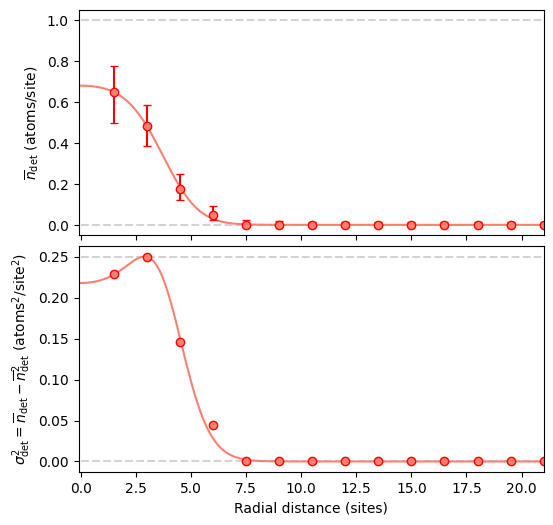

In [57]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), dpi=100, sharex=True)
fig.subplots_adjust(hspace=0.05)

axs[0].set_ylabel('$\overline{n}_{\mathrm{det}}$ (atoms/site)')
axs[1].set_ylabel('$\sigma^2_{\mathrm{det}} = \overline{n}_{\mathrm{det}} - \overline{n}^2_{\mathrm{det}}$ (atoms$^2$/site$^2$)')

axs[0].errorbar(r_sites, n_occupied, yerr=n_occupied_std, fmt='o', c='r', mfc='salmon', mec='r', capsize=3)
axs[0].plot(r_fit, n_occupied_fit, '-', c='salmon', zorder=-5)
axs[0].hlines(1, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

axs[1].errorbar(r_sites, n_occupied - n_occupied**2, fmt='o', c='r', mfc='salmon', mec='r', capsize=3)
axs[1].plot(r_fit, n_occupied_fit - n_occupied_fit**2, '-', c='salmon', zorder=-5)
axs[1].hlines(0.25, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

axs[0].set_xlim(-0.1, int(15/a_mean))
axs[1].set_xlabel('Radial distance (sites)')

for ax in axs:
    ax.hlines(0, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

plt.show()

In [58]:
Sloc_eval, Nreal_eval = calc_Sloc(r_fit, *p_fit_occupied)

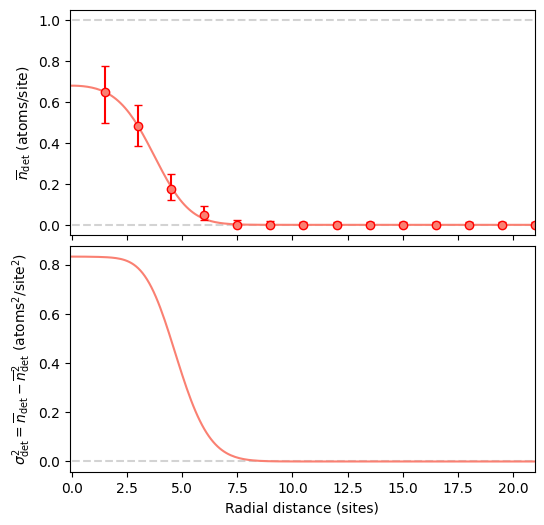

In [59]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), dpi=100, sharex=True)
fig.subplots_adjust(hspace=0.05)

axs[0].set_ylabel('$\overline{n}_{\mathrm{det}}$ (atoms/site)')
axs[1].set_ylabel('$\sigma^2_{\mathrm{det}} = \overline{n}_{\mathrm{det}} - \overline{n}^2_{\mathrm{det}}$ (atoms$^2$/site$^2$)')

axs[0].errorbar(r_sites, n_occupied, yerr=n_occupied_std, fmt='o', c='r', mfc='salmon', mec='r', capsize=3)
axs[0].plot(r_fit, n_occupied_fit, '-', c='salmon', zorder=-5)
axs[0].hlines(1, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

axs[1].plot(r_fit, Sloc_eval/constants.k, '-', c='salmon', zorder=-5)
# axs[1].hlines(0.25, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

axs[0].set_xlim(-0.1, int(15/a_mean))
axs[1].set_xlabel('Radial distance (sites)')

for ax in axs:
    ax.hlines(0, xmin=-1, xmax=100, color='lightgray', ls='--', zorder=-10)

plt.show()

In [60]:
N_dec = len(xs_dec)
Stotal_eval = np.sum(Sloc_eval/constants.k)

In [61]:
N_dec, Stotal_eval, Stotal_eval/N_dec

(40, np.float64(41.34996224815331), np.float64(1.0337490562038327))

In [62]:
np.sum(Nreal_eval), Stotal_eval, Stotal_eval/np.sum(Nreal_eval)

(np.float64(31.031688235611284),
 np.float64(41.34996224815331),
 np.float64(1.3325076590805975))

In [63]:
Ntotal, S_total, S_total/Ntotal

(np.float64(47.643506044484),
 np.float64(36.714531753358266),
 np.float64(0.7706093610969453))